Lets Start by importing libraries  

In [79]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


Load the Data and check for any problem in data missing values etc.

In [80]:
df=pd.read_csv('data_tempvsice.csv')


In [81]:
print(df.head())
print(df.info())


   temperature_c  ice_cream_sales
0          32.57           285.34
1          24.27           214.91
2          27.61           246.19
3           9.18            89.77
4           7.62            77.50
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temperature_c    100 non-null    float64
 1   ice_cream_sales  100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB
None


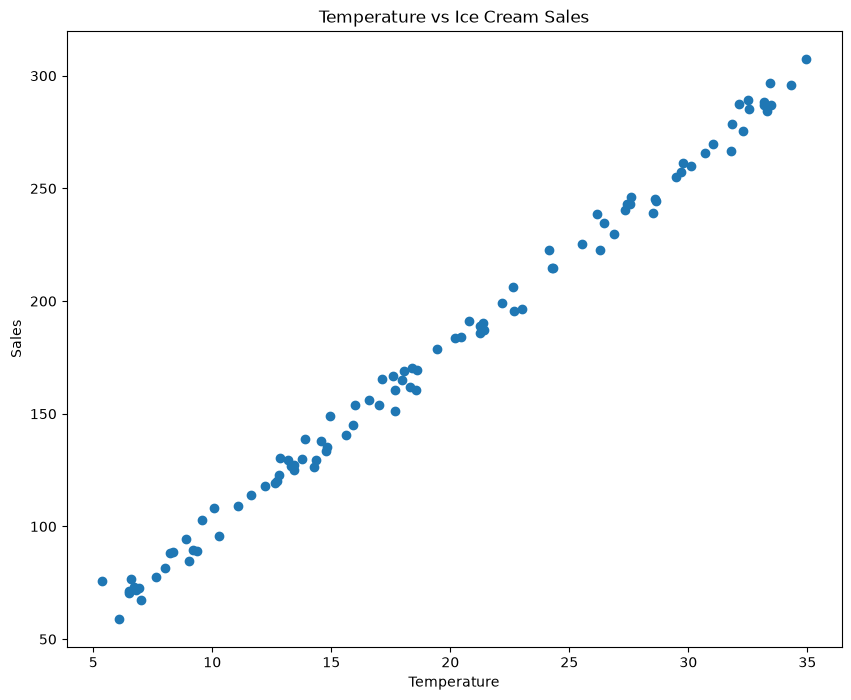

In [82]:
plt.figure(figsize=(10, 8))
plt.scatter(df.temperature_c, df.ice_cream_sales)
plt.title("Temperature vs Ice Cream Sales")
plt.xlabel("Temperature")
plt.ylabel("Sales")
plt.show()



In [84]:

# 1. Convert to NumPy arrays directly
X = df['temperature_c'].values.astype(float)
Y = df['ice_cream_sales'].values.astype(float)

# 2. Compute means instantly using np.mean()
meanX = np.mean(X)
meanY = np.mean(Y)

print(f"Mean of X: {meanX}")
print(f"Mean of Y: {meanY}")

# 3. Vectorized calculations (Removes all 3 'for' loops)
Xm = X - meanX
Ym = Y - meanY
XmY = Xm * Ym

# 4. Compute slope using vectorized sum and squaring
m = np.sum(XmY) / np.sum(Xm**2)

print(f"Beta 1 or Slope is : {m:.4f}")
b=meanY-meanX*m
print(f"Beta 0 or Bias is :{b:.4f}")


Mean of X: 19.3894
Mean of Y: 175.43180000000004
Beta 1 or Slope is : 8.0883
Beta 0 or Bias is :18.6038


lets calculate optimal m and b for our data so we can get MSE

In [ ]:
#Values of X-axis and Y-axis
Y=df['ice_cream_sales'].values.astype(float)
X=df['temperature_c'].values.astype(float)

m=0.0
b=0.0

learning_rate = 0.0001
epochs=1000
n=len(X)

for epoch in range(epochs):
    dm=0    #derivative with respect to m(slop)
    db=0    #derivative with respect to b(bias/constant/starting point of y)
    sse=0.0
    for i in range(n):
        y_pred=m*X[i]+b
        error=Y[i]-y_pred

        dm+=(-2/n)*X[i]*error
        db+=(-2/n)*error
        sse+= error**2
        # print(f"Original Value :{Y[i]} ")
        # print(f"Predicted Value :{y_pred} ")

    m-= learning_rate*dm
    b-= learning_rate*db
    mse = sse/n


print(f"Beta 0/Bias/Intercept(b): {b:.3f}")
print(f"Beta 1/Slope(m) is : {m:.3f}")
print(f"Mean Squared Error is :{mse:.3f}")





Beta 0/Bias/Intercept(b): 0.975
Beta 1/Slope(m) is : 8.847
Mean Squared Error is :76.321


In [63]:

# Load values safely as floats
# Convert to native NumPy arrays explicitly to appease the static type checker
X = np.array(df['temperature_c'], dtype=float)
Y = np.array(df['ice_cream_sales'], dtype=float)


# Initial parameters
m, b = 0.0, 0.0

# Hyperparameters
learning_rate = 0.0001
epochs = 50000  # Increased from 1000 so the intercept can fully converge
n = len(X)

# Vectorized optimization loop (No slow row-by-row loops)
for epoch in range(epochs):
    y_pred = m * X + b
    error = Y - y_pred
    
    # Calculate gradients across all rows simultaneously
    dm = (-2 / n) * np.sum(X * error)
    db = (-2 / n) * np.sum(error)
    
    # Update rules for each time
    m -= learning_rate * dm
    b -= learning_rate * db
    mse = np.mean(error ** 2)
    # Progress monitor: Prints only once every 5000 epochs instead of every row
    if epoch % 5000 == 0:
        print(f"Epoch {epoch:5d} | Intercept (b): {b:.3f} | Slope (m): {m:.3f}")

print("\n--- Final Fully Converged Model ---")
print(f"Beta 0 / Bias / Intercept (b): {b:.3f}")
print(f"Beta 1 / Slope (m) is : {m:.3f}")
print(f"MSE Mean Squared Error is : {mse:.3f}")


Epoch     0 | Intercept (b): 0.035 | Slope (m): 0.801
Epoch  5000 | Intercept (b): 3.162 | Slope (m): 8.753
Epoch 10000 | Intercept (b): 5.518 | Slope (m): 8.652
Epoch 15000 | Intercept (b): 7.514 | Slope (m): 8.566
Epoch 20000 | Intercept (b): 9.205 | Slope (m): 8.493
Epoch 25000 | Intercept (b): 10.639 | Slope (m): 8.431
Epoch 30000 | Intercept (b): 11.854 | Slope (m): 8.379
Epoch 35000 | Intercept (b): 12.884 | Slope (m): 8.335
Epoch 40000 | Intercept (b): 13.756 | Slope (m): 8.297
Epoch 45000 | Intercept (b): 14.496 | Slope (m): 8.265

--- Final Fully Converged Model ---
Beta 0 / Bias / Intercept (b): 15.122
Beta 1 / Slope (m) is : 8.238
MSE Mean Squared Error is : 26.796


In [85]:
def predict_sales(temperature):
    """Calculates expected ice cream sales based on our trained model weights."""
    return (m * temperature) + b

# --- Test Scenarios ---
cool_day = 15.0
hot_day = 32.0
user_temp=float(input("Enter Temperature to predict sales :"))
print(f"Predicted sales at {cool_day}°C: ${predict_sales(cool_day):.2f}")
print(f"Predicted sales at {hot_day}°C: ${predict_sales(hot_day):.2f}")
print(f"Predicted sakes at {user_temp} °C: ${predict_sales(user_temp):.3f}")


Predicted sales at 15.0°C: $139.93
Predicted sales at 32.0°C: $277.43
Predicted sakes at 32.0 °C: $277.431


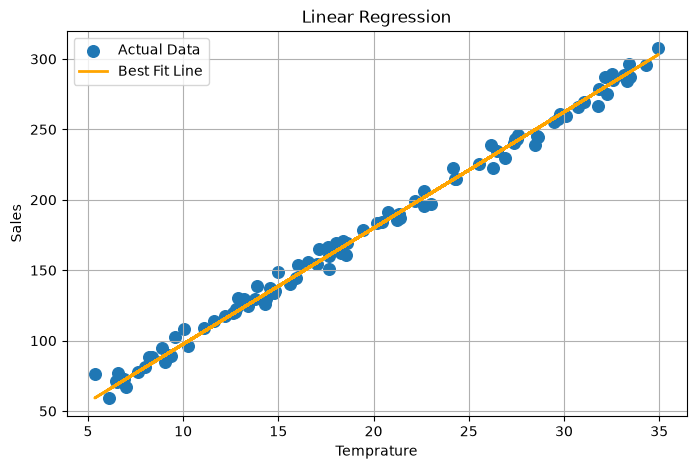

In [86]:
# -----------------------------
# Scatter Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.scatter(X, Y, label="Actual Data", s=70)

# Best Fit Line
plt.plot(X, y_pred, label="Best Fit Line", linewidth=2,color="orange")

plt.title("Linear Regression")
plt.xlabel("Temprature")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()


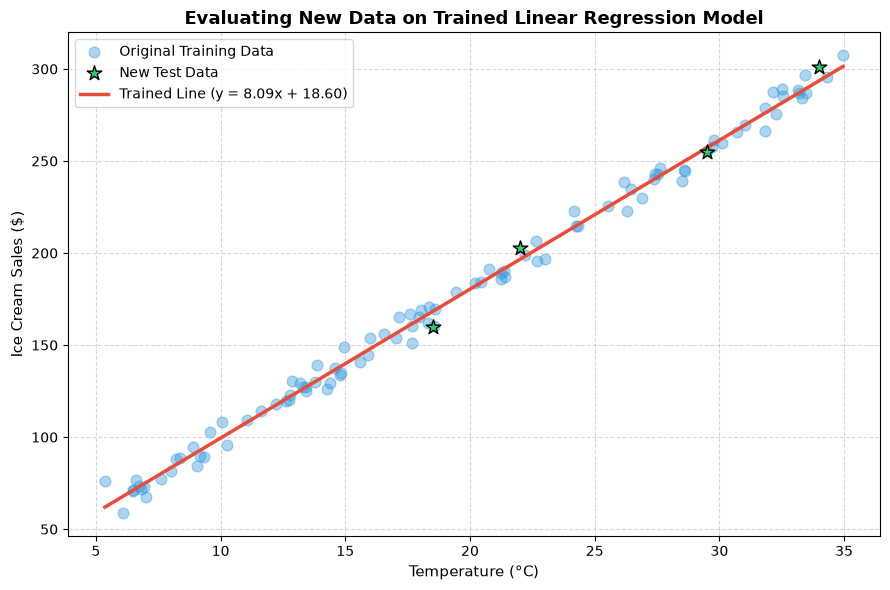

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Your Existing Trained Parameters ---
# (Using the converged m and b from your previous 50,000 epoch run)
# m = 8.238
# b = 15.122

# --- 2. Define Your NEW Data Points ---
# Example: 4 days with temperatures and their actual recorded ice cream sales
X_new = np.array([18.5, 22.0, 29.5, 34.0], dtype=float)
Y_new = np.array([160.0, 202.5, 255.0, 301.0], dtype=float)

# --- 3. Generate the Canvas ---
plt.figure(figsize=(9, 6))

# Plot Original Training Data (Fade it slightly with alpha=0.4 to make new data pop)
plt.scatter(X, Y, color="#3498db", label="Original Training Data", s=60, alpha=0.4)

# Plot NEW Data Points (Use a distinct color like green or orange and a star marker)
plt.scatter(X_new, Y_new, color="#2ecc71", label="New Test Data", s=120, marker="*", edgecolors="black", zorder=5)

# --- 4. Plot Your Trained Best Fit Line ---
# Create a line path spanning across both old and new data boundaries
all_x = np.concatenate([X, X_new])
X_line = np.linspace(all_x.min(), all_x.max(), 100)
y_line = m * X_line + b

plt.plot(X_line, y_line, color="#e74c3c", label=f"Trained Line (y = {m:.2f}x + {b:.2f})", linewidth=2.5)

# --- 5. Labels and Visual Styling ---
plt.title("Evaluating New Data on Trained Linear Regression Model", fontsize=13, fontweight="bold")
plt.xlabel("Temperature (°C)", fontsize=11)
plt.ylabel("Ice Cream Sales ($)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", frameon=True)

# --- 6. Show the graph ---
plt.tight_layout()
plt.show()
